# Baseline Comparison
This notebook loads `results/baseline_summary.json` and compares the heuristic controllers across evaluation regimes.

In [12]:
import json
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

In [13]:
RESULT_PATH = Path("../results/baseline_summary.json")

with open(RESULT_PATH, "r") as f:
    baseline_data = json.load(f)

rows = []
for regime, policies in baseline_data.items():
    for policy, metrics in policies.items():
        row = {"regime": regime, "policy": policy}
        row.update(metrics)
        rows.append(row)

baseline_df = pd.DataFrame(rows)
baseline_df

,regime,policy,total_reward,average_queue_length,maximum_queue_length,throughput_per_step,total_departed,average_wait_time_steps,average_wait_time_seconds,switch_count,switch_requested_count,switch_applied_count,invalid_switch_count
0,symmetric_low,fixed_cycle,-1977.95,9.70975,22.70,1.98700,397.40,4.852487,14.557462,18.00,18.00,18.00,0.0
1,symmetric_low,queue_threshold,-1308.50,6.25250,14.60,1.98600,397.20,3.100628,9.301883,29.00,29.00,29.00,0.0
2,symmetric_low,max_pressure,-1156.60,5.16150,13.35,1.99025,398.05,2.561741,7.685224,62.15,62.15,62.15,0.0
3,symmetric_high,fixed_cycle,-5529.30,27.46650,46.60,4.67200,934.40,5.751709,17.255126,18.00,18.00,18.00,0.0
4,symmetric_high,queue_threshold,-3607.20,17.57050,32.25,4.72575,945.15,3.659219,10.977656,46.55,46.55,46.55,0.0
5,symmetric_high,max_pressure,-4267.75,20.69925,37.45,4.71450,942.90,4.307782,12.923346,63.95,63.95,63.95,0.0
6,asymmetric,fixed_cycle,-4443.80,22.03900,47.70,3.76125,752.25,5.814883,17.444649,18.00,18.00,18.00,0.0
7,asymmetric,queue_threshold,-2399.60,11.65350,26.25,3.76475,752.95,3.050725,9.152174,34.45,34.45,34.45,0.0
8,asymmetric,max_pressure,-2365.65,11.27775,24.50,3.76900,753.80,2.951194,8.853582,55.05,55.05,55.05,0.0
9,nonstationary,fixed_cycle,-3111.85,15.37925,42.55,2.89175,578.35,5.254305,15.762914,18.00,18.00,18.00,0.0


In [14]:
display(
    baseline_df.sort_values(["regime", "average_queue_length"])[
        [
            "regime",
            "policy",
            "average_queue_length",
            "average_wait_time_seconds",
            "throughput_per_step",
            "switch_count",
            "invalid_switch_count",
            "total_reward",
        ]
    ]
)

,regime,policy,average_queue_length,average_wait_time_seconds,throughput_per_step,switch_count,invalid_switch_count,total_reward
8,asymmetric,max_pressure,11.27775,8.853582,3.76900,55.05,0.0,-2365.65
7,asymmetric,queue_threshold,11.65350,9.152174,3.76475,34.45,0.0,-2399.60
6,asymmetric,fixed_cycle,22.03900,17.444649,3.76125,18.00,0.0,-4443.80
14,burst_east_west,max_pressure,10.11150,9.102961,3.30000,61.90,0.0,-2146.10
13,burst_east_west,queue_threshold,10.58550,9.519879,3.29775,38.45,0.0,-2194.00
12,burst_east_west,fixed_cycle,18.06700,16.355808,3.27900,18.00,0.0,-3649.40
11,nonstationary,max_pressure,8.83700,8.985972,2.90625,61.25,0.0,-1889.90
10,nonstationary,queue_threshold,9.40400,9.558142,2.90150,34.00,0.0,-1948.80
9,nonstationary,fixed_cycle,15.37925,15.762914,2.89175,18.00,0.0,-3111.85
4,symmetric_high,queue_threshold,17.57050,10.977656,4.72575,46.55,0.0,-3607.20


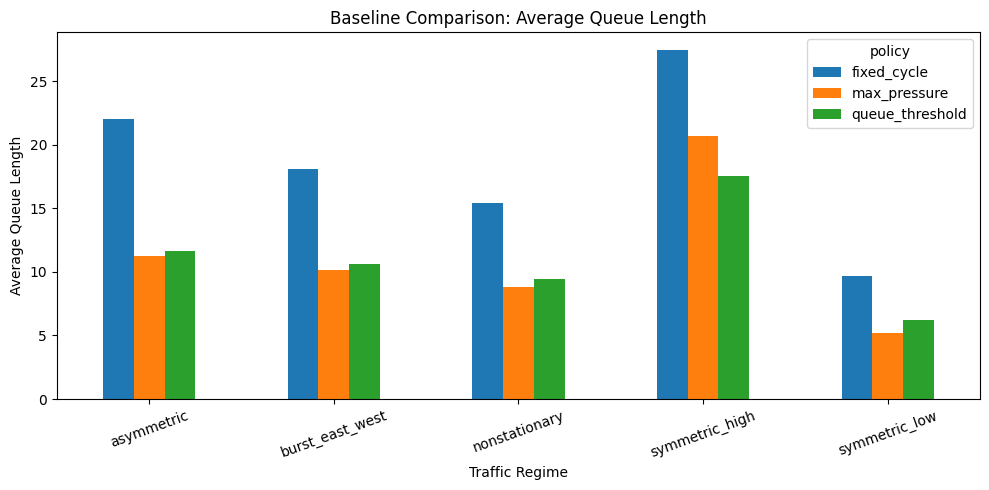

In [15]:
pivot_queue = baseline_df.pivot(index="regime", columns="policy", values="average_queue_length")
pivot_queue.plot(kind="bar", figsize=(10, 5))
plt.title("Baseline Comparison: Average Queue Length")
plt.ylabel("Average Queue Length")
plt.xlabel("Traffic Regime")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

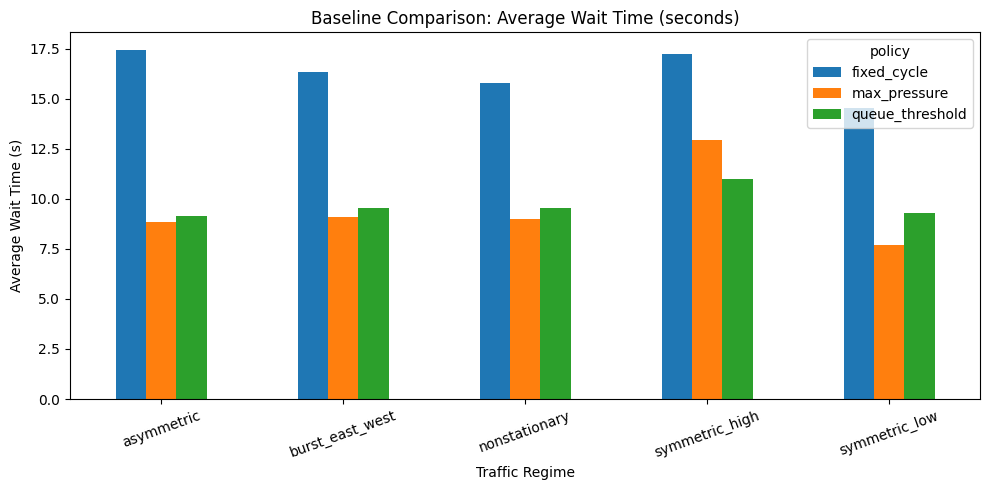

In [16]:
pivot_wait = baseline_df.pivot(index="regime", columns="policy", values="average_wait_time_seconds")
pivot_wait.plot(kind="bar", figsize=(10, 5))
plt.title("Baseline Comparison: Average Wait Time (seconds)")
plt.ylabel("Average Wait Time (s)")
plt.xlabel("Traffic Regime")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

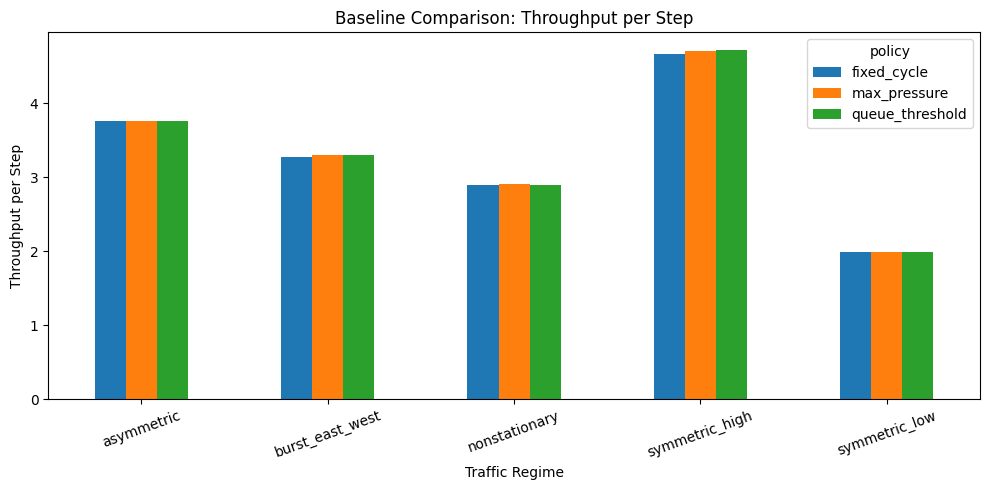

In [17]:
pivot_throughput = baseline_df.pivot(index="regime", columns="policy", values="throughput_per_step")
pivot_throughput.plot(kind="bar", figsize=(10, 5))
plt.title("Baseline Comparison: Throughput per Step")
plt.ylabel("Throughput per Step")
plt.xlabel("Traffic Regime")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

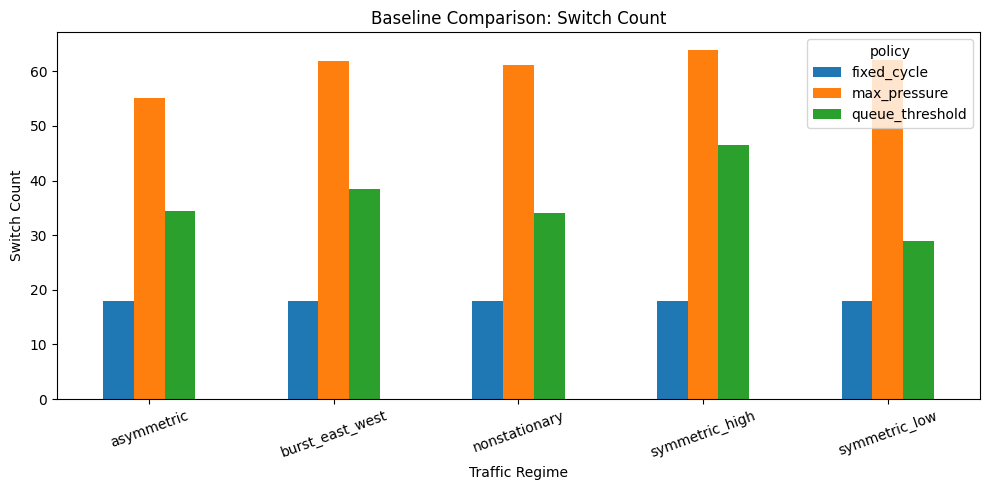

In [18]:
pivot_switch = baseline_df.pivot(index="regime", columns="policy", values="switch_count")
pivot_switch.plot(kind="bar", figsize=(10, 5))
plt.title("Baseline Comparison: Switch Count")
plt.ylabel("Switch Count")
plt.xlabel("Traffic Regime")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

In [19]:
winner_queue = baseline_df.loc[
    baseline_df.groupby("regime")["average_queue_length"].idxmin(),
    ["regime", "policy", "average_queue_length"]
].sort_values("regime")

winner_wait = baseline_df.loc[
    baseline_df.groupby("regime")["average_wait_time_seconds"].idxmin(),
    ["regime", "policy", "average_wait_time_seconds"]
].sort_values("regime")

display(winner_queue)
display(winner_wait)

,regime,policy,average_queue_length
8,asymmetric,max_pressure,11.27775
14,burst_east_west,max_pressure,10.11150
11,nonstationary,max_pressure,8.83700
4,symmetric_high,queue_threshold,17.57050
2,symmetric_low,max_pressure,5.16150


,regime,policy,average_wait_time_seconds
8,asymmetric,max_pressure,8.853582
14,burst_east_west,max_pressure,9.102961
11,nonstationary,max_pressure,8.985972
4,symmetric_high,queue_threshold,10.977656
2,symmetric_low,max_pressure,7.685224


## Current Key observations
- The strongest heuristic baseline is regime-dependent, but max-pressure performs best in 4 of the 5 evaluation regimes, while queue-threshold performs best only in the symmetric-high regime.
- Fixed-cycle is consistently the weakest controller on congestion metrics, especially under asymmetric, nonstationary, and bursty traffic.
- The largest differences across baselines appear in average queue length and average wait time, while throughput differences are comparatively smaller.
- Max-pressure achieves the best congestion reduction overall, but it also switches much more frequently than the other baselines, indicating a trade-off between traffic efficiency and switching intensity.